# ML Course Season 2
## Практика: Подбор гиперпараметров и интерпретируемость моделей

В этом ноутбуке мы:
1. Подберём гиперпараметры нескольких моделей с помощью Grid Search и Random Search
2. Настроим Pipeline с совместным подбором препроцессинга и модели
3. Интерпретируем результаты через Permutation Importance, PDP/ICE и SHAP
4. Научимся диагностировать подозрительные признаки

**Датасет:** [Wine Quality](https://scikit-learn.org/stable/datasets/toy_dataset.html) и Breast Cancer Wisconsin (sklearn)

---

## Шаг 1. Импорты и загрузка данных

Загрузим датасет Breast Cancer Wisconsin и познакомимся с ним.

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# Загружаем датасет
data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target
feature_names = data.feature_names

print(data.DESCR[:600])

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concav


In [67]:
# Разбиваем данные
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Распределение классов в train: {y_train.value_counts().to_dict()}")

Train: (455, 30), Test: (114, 30)
Распределение классов в train: {1: 285, 0: 170}


## Шаг 2. Базовые модели без тюнинга

Обучим несколько моделей с дефолтными параметрами, чтобы иметь точку отсчёта.

In [68]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score

# Словарь базовых моделей
base_models = {
    'SVM': Pipeline([('scaler', StandardScaler()), ('clf', SVC(random_state=42))]),
    'RandomForest': RandomForestClassifier(random_state=42),
    'LogisticRegression': Pipeline([('scaler', StandardScaler()),
                                    ('clf', LogisticRegression(random_state=42))]),
}

baseline_results = {}


# ╔══════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 2а: Для каждой модели в base_models         ║
# ║  вычислите 5-fold CV с scoring='f1_macro'            ║
# ║  Сохраните mean и std в baseline_results             ║
# ╚══════════════════════════════════════════════════════╝

for name, model in base_models.items():
    scores = cross_val_score(model, X_test, y_test, cv=5, scoring='f1_macro')
    baseline_results[name] = (np.mean(scores), np.std(scores))


# После заполнения — вывод результатов:
for name, (mean, std) in baseline_results.items():
    print(f"{name:25s} F1 = {mean:.4f} ± {std:.4f}")

SVM                       F1 = 0.9414 ± 0.0375
RandomForest              F1 = 0.9417 ± 0.0222
LogisticRegression        F1 = 0.9414 ± 0.0375


## Шаг 3. Grid Search для SVM

Подберём гиперпараметры SVM с помощью перебора сетки через Pipeline.

In [69]:
from sklearn.model_selection import GridSearchCV

# Pipeline: нормировка + SVM
svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42, probability=True)),
])

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3а: Задайте сетку параметров для GridSearchCV       ║
# ║  Параметры SVM через Pipeline: 'svm__C', 'svm__gamma',       ║
# ║  'svm__kernel'                                               ║
# ║  Попробуйте: C in [0.1, 1, 10, 100],                         ║
# ║  gamma in ['scale', 0.01, 0.001], kernel in ['rbf','linear'] ║
# ╚══════════════════════════════════════════════════════════════╝

svm_param_grid = {
    'svm__C' : [0.1, 1, 10, 100],
    'svm__gamma' : ['scale', 0.01, 0.001],
    'svm__kernel' : ['rbf', 'linear']
}

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3б: Создайте и запустите GridSearchCV               ║
# ║  cv=5, scoring='f1_macro', n_jobs=-1                         ║
# ╚══════════════════════════════════════════════════════════════╝

svm_grid_search = GridSearchCV(
    estimator=svm_pipe,           # модель
    param_grid=svm_param_grid,    # сетка параметров
    cv=5,                         # кросс-валидация
    scoring='f1_macro',           # метрика
    n_jobs=-1,                    # параллельные вычисления
    return_train_score=True       # вернуть train scores
)
svm_grid_search.fit(X_train, y_train)

print(f"Лучшие параметры SVM: {svm_grid_search.best_params_}")
print(f"Лучший CV F1: {svm_grid_search.best_score_:.4f}")

Лучшие параметры SVM: {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Лучший CV F1: 0.9786


In [70]:
# Анализируем результаты Grid Search

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3в: Создайте DataFrame из svm_grid_search.cv_results║
# ║  Выберите колонки: params, mean_test_score, std_test_score,  ║
# ║  rank_test_score                                             ║
# ║  Выведите топ-10 конфигураций                                ║
# ╚══════════════════════════════════════════════════════════════╝

df_config = pd.DataFrame(svm_grid_search.cv_results_)

top_10 = df_config[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
top_10 = top_10.sort_values('rank_test_score').head(10)

print(top_10)

                                               params  mean_test_score  \
14  {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kerne...         0.978633   
1   {'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__k...         0.976215   
5   {'svm__C': 0.1, 'svm__gamma': 0.001, 'svm__ker...         0.976215   
3   {'svm__C': 0.1, 'svm__gamma': 0.01, 'svm__kern...         0.976215   
22  {'svm__C': 100, 'svm__gamma': 0.001, 'svm__ker...         0.976157   
16  {'svm__C': 10, 'svm__gamma': 0.001, 'svm__kern...         0.971340   
6   {'svm__C': 1, 'svm__gamma': 'scale', 'svm__ker...         0.969357   
12  {'svm__C': 10, 'svm__gamma': 'scale', 'svm__ke...         0.969350   
20  {'svm__C': 100, 'svm__gamma': 0.01, 'svm__kern...         0.966936   
8   {'svm__C': 1, 'svm__gamma': 0.01, 'svm__kernel...         0.966732   

    std_test_score  rank_test_score  
14        0.017581                1  
1         0.015266                2  
5         0.015266                2  
3         0.015266               

## Шаг 4. Random Search для RandomForest

Теперь подберём гиперпараметры RandomForest с помощью случайного поиска.

In [71]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, loguniform

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4а: Задайте пространство параметров для             ║
# ║  RandomizedSearchCV на RandomForestClassifier                ║
# ║  Попробуйте:                                                 ║
# ║    n_estimators: randint(50, 500)                            ║
# ║    max_depth: randint(2, 20) или None                        ║
# ║    min_samples_split: randint(2, 20)                         ║
# ║    max_features: ['sqrt', 'log2', 0.5]                       ║
# ╚══════════════════════════════════════════════════════════════╝

rf_param_dist = {
    "n_estimators": randint(50, 500),
    "max_depth": randint(2, 20),
    "min_samples_split": randint(2, 20), 
    "max_features": ['sqrt', 'log2', 0.5]

}

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4б: Создайте RandomizedSearchCV                     ║
# ║  n_iter=50, cv=5, scoring='f1_macro',                        ║
# ║  random_state=42, n_jobs=-1                                  ║
# ║  Обучите на X_train, y_train                                 ║
# ╚══════════════════════════════════════════════════════════════╝

rf_random_search = RandomizedSearchCV(n_iter=50, cv=5, scoring='f1_macro', random_state=42, n_jobs=-1, param_distributions=rf_param_dist, estimator=RandomForestClassifier())

rf_random_search.fit(X_train, y_train)

print(f"Лучшие параметры RF: {rf_random_search.best_params_}")
print(f"Лучший CV F1: {rf_random_search.best_score_:.4f}")

Лучшие параметры RF: {'max_depth': 11, 'max_features': 'sqrt', 'min_samples_split': 8, 'n_estimators': 290}
Лучший CV F1: 0.9577


## Шаг 5. Сравнение результатов

Сравним: baseline vs Grid Search vs Random Search. И проведём финальную оценку на тесте.

In [72]:
from sklearn.metrics import classification_report

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 5: Оцените лучшие модели (svm_grid_search и         ║
# ║  rf_random_search) на тестовой выборке X_test, y_test        ║
# ║                                                              ║
# ║  Для каждой модели выведите classification_report            ║
# ║  Сравните с baseline моделями из шага 2                      ║
# ║                                                              ║
# ║  ВАЖНО: тест используем ТОЛЬКО ЗДЕСЬ, один раз!             ║
# ╚══════════════════════════════════════════════════════════════╝

y_pred_svm_best = svm_grid_search.predict(X_test)
y_pred_rf_best = rf_random_search.predict(X_test)

base_models['SVM'].fit(X_train, y_train)
y_pred_SVM_base = base_models['SVM'].predict(X_test)
base_models['RandomForest'].fit(X_train, y_train)
y_pred_rf_base = base_models['RandomForest'].predict(X_test)

print("=" * 60)
print("SVM Grid Search best")
print("=" * 60)
print(classification_report(y_test, y_pred_svm_best))

print("=" * 60)
print("Random Forest Random Search best")
print("=" * 60)
print(classification_report(y_test, y_pred_rf_best))


# Заполните таблицу:
# | Модель                | CV F1 (mean±std) | Test F1 |
# |-----------------------|------------------|---------|
# | SVM baseline          |                  |         |
# | SVM Grid Search       |                  |         |
# | RF baseline           |                  |         |
# | RF Random Search      |                  |         |


# Таблица

print(f"SVM baseline - CV F1: {baseline_results['SVM'][0]:.4f}, Test F1: {f1_score(y_test, y_pred_SVM_base, average='macro'):.4f}")
print(f"SVM Grid Search - CV F1: {svm_grid_search.best_score_:.4f}, Test F1: {f1_score(y_test, y_pred_svm_best, average='macro'):.4f}")
print(f"RF baseline - CV F1: {baseline_results['RandomForest'][0]:.4f}, Test F1: {f1_score(y_test, y_pred_rf_base, average='macro'):.4f}")
print(f"RF Random Search - CV F1: {rf_random_search.best_score_:.4f}, Test F1: {f1_score(y_test, y_pred_rf_best, average='macro'):.4f}")

SVM Grid Search best
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

Random Forest Random Search best
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

SVM baseline - CV F1: 0.9414, Test F1: 0.9812
SVM Grid Search - CV F1: 0.9786, Test F1: 0.9812
RF baseline - CV F1: 0.9417, Test F1: 0.9526
RF Random Search - CV F1: 0.9577, Test F1: 0.9526


## Шаг 6. Permutation Importance

Посмотрим, какие признаки важны для лучшей модели.

<BarContainer object of 10 artists>

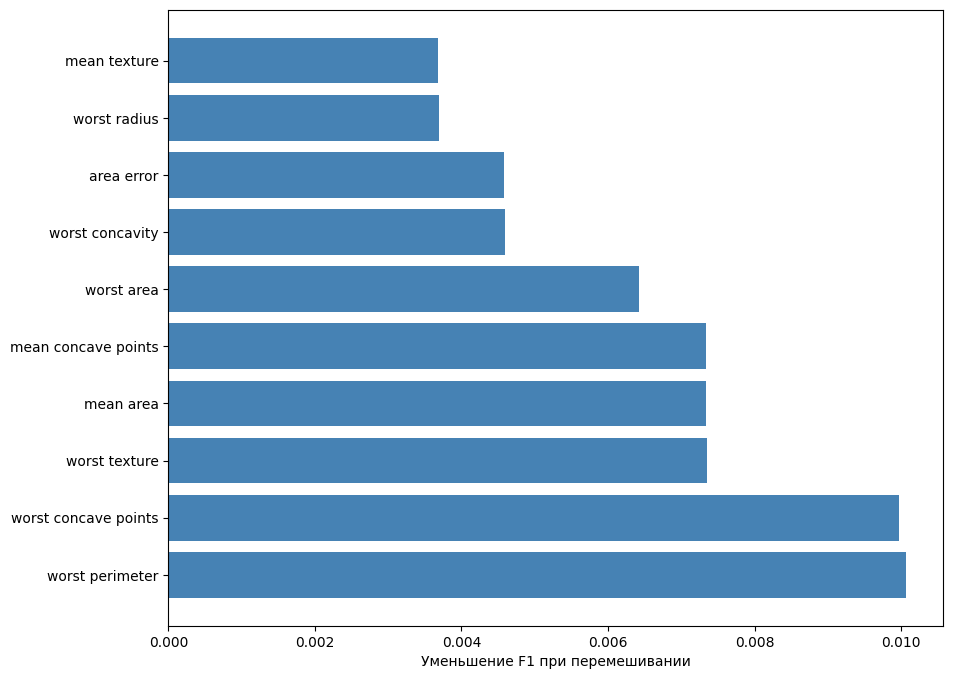

In [ ]:
from sklearn.inspection import permutation_importance

# Используем лучший RF из Random Search
best_rf = rf_random_search.best_estimator_

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 6а: Вычислите Permutation Importance                ║
# ║  для best_rf на X_test, y_test                               ║
# ║  n_repeats=10, random_state=42, scoring='f1_macro'           ║
# ╚══════════════════════════════════════════════════════════════╝


pi_result = permutation_importance(estimator=best_rf, X=X_test, y=y_test, n_repeats=10, random_state=42, scoring='f1_macro')

# Построим bar plot топ-10 признаков
sorted_idx = np.argsort(pi_result['importances_mean'])[::-1][:10]

top_10 = pi_result['importances_mean'][sorted_idx]

top_10_names = X_test.columns[sorted_idx]

fig, axes = plt.subplots(figsize=(10, 8))

axes.set_yticks(range(10))
axes.set_yticklabels([s for s in top_10_names])
axes.set_xlabel('изм F1 при перемешивании')
axes.barh(range(10), top_10, capsize=3, color='steelblue')



In [79]:
# Встроенная важность RF (для сравнения)

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 6б: Сравните Permutation Importance                 ║
# ║  с встроенной feature_importances_ RandomForest              ║
# ║  Совпадает ли порядок топ-5 признаков?                       ║
# ║  Если нет — как вы это объясняете?                           ║
# ╚══════════════════════════════════════════════════════════════╝

rf_feature_importance = best_rf.feature_importances_

comparison_df = pd.DataFrame({
    'feature': X_test.columns,
    'permutation_importance': pi_result['importances_mean'],
    'rf_importance': rf_feature_importance
})

comparison_df = comparison_df.sort_values('permutation_importance', ascending=False)

top5_perm = comparison_df.head(5)['feature'].tolist()
top5_rf = comparison_df.sort_values('rf_importance', ascending=False).head(5)['feature'].tolist()

print("=" * 60)
print("Сравнение топ-5 признаков")
print("=" * 60)
print(f"Топ-5 по Permutation Importance: {top5_perm}")
print(f"Топ-5 по встроенной важности RF:  {top5_rf}")
print()

comparison_df

# Вопрос для размышления:
# Некоторые признаки имеют высокий PI, но низкую встроенную важность,
# или наоборот. Что это может означать?

Сравнение топ-5 признаков
Топ-5 по Permutation Importance: ['worst perimeter', 'worst concave points', 'worst texture', 'mean area', 'mean concave points']
Топ-5 по встроенной важности RF:  ['worst perimeter', 'worst concave points', 'worst radius', 'mean concave points', 'worst area']



,feature,permutation_importance,rf_importance
22,worst perimeter,0.010072,0.150084
27,worst concave points,0.009974,0.129022
21,worst texture,0.007349,0.013723
3,mean area,0.007340,0.057321
7,mean concave points,0.007332,0.102984
23,worst area,0.006422,0.085038
26,worst concavity,0.004593,0.033665
13,area error,0.004585,0.037583
20,worst radius,0.003688,0.125266
1,mean texture,0.003674,0.013759


## Шаг 7. PDP и ICE-кривые

Визуализируем эффект наиболее важных признаков.

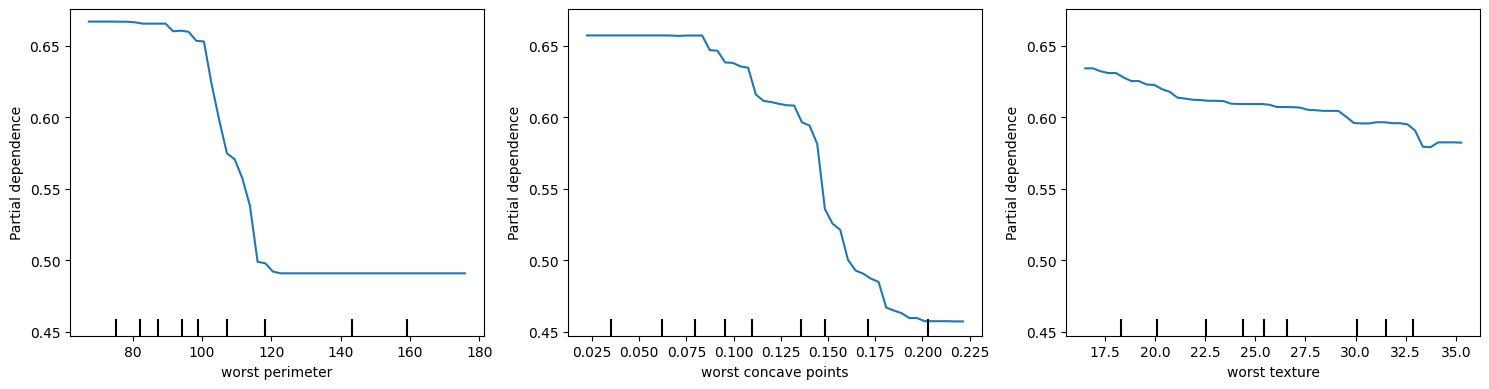

Топ-3 признака по Permutation Importance:
1. worst perimeter
2. worst concave points
3. worst texture


In [ ]:
from sklearn.inspection import PartialDependenceDisplay

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 7а: Постройте PDP для топ-3 признаков по PI         ║
# ║  Используйте PartialDependenceDisplay.from_estimator         ║
# ║  kind='average' для PDP                                      ║
# ╚══════════════════════════════════════════════════════════════╝

# Определите индексы топ-3 признаков по PI
top3_idx = np.argsort(pi_result['importances_mean'])[::-1][:3]

# Постройте PDP
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

PartialDependenceDisplay.from_estimator(
    best_rf,
    X_test,
    features=top3_idx,
    kind='average',
    ax=ax,
    grid_resolution=50
)

plt.tight_layout()
plt.show()

top3_names = X_test.columns[top3_idx]
print("Топ-3 признака по Permutation Importance:")
for i, name in enumerate(top3_names):
    print(f"{i+1}. {name}")

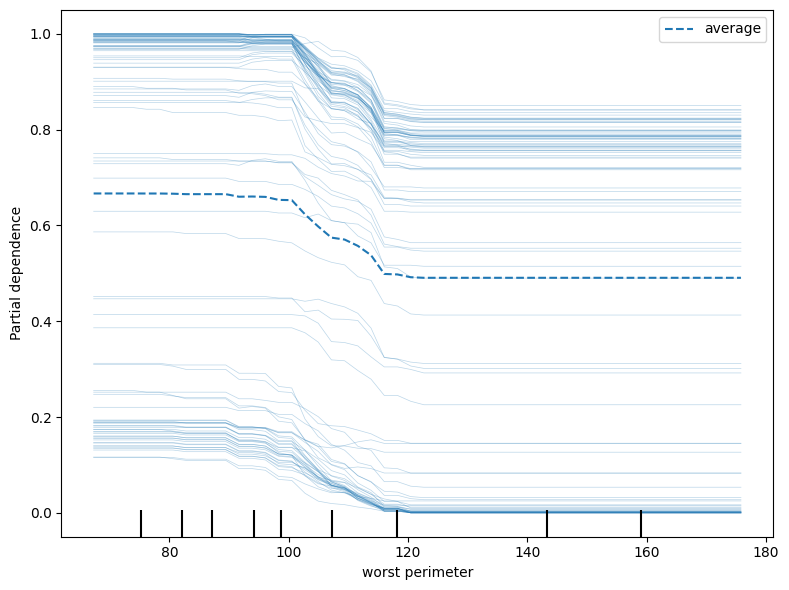

In [83]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 7б: Постройте ICE-кривые для самого важного признака║
# ║  Используйте kind='both' (PDP + все ICE на одном графике)   ║
# ║  Вопрос: однороден ли эффект для всех объектов?              ║
# ╚══════════════════════════════════════════════════════════════╝
top1_idx = np.argsort(pi_result['importances_mean'])[::-1][0]

fig, ax = plt.subplots(figsize=(8, 6))

PartialDependenceDisplay.from_estimator(
    best_rf,
    X_test,
    features=[top1_idx],          # самый важный признак
    kind='both',                  # PDP + все ICE на одном графике
    ax=ax,
    grid_resolution=50,
    subsample=100                 # ограничиваем количество ICE-линий (для читаемости)
)

plt.tight_layout()
plt.show()

## Шаг 8. SHAP

Интерпретируем модель с помощью SHAP — глобально и локально.

In [93]:
# Установка SHAP (если не установлен)
# !pip install shap

import shap

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8а: Создайте TreeExplainer для best_rf              ║
# ║  Вычислите shap_values для X_test                            ║
# ║  Выведите форму массива shap_values                          ║
# ╚══════════════════════════════════════════════════════════════╝

# Создаём TreeExplainer для Random Forest
explainer = shap.TreeExplainer(best_rf)

# Вычисляем SHAP-значения для тестовой выборки
shap_values = explainer.shap_values(X_test)


print("Форма shap_values:", shap_values.shape if hasattr(shap_values, 'shape') else len(shap_values))

if isinstance(shap_values, list):
    print(f"Количество классов: {len(shap_values)}")
    for i, arr in enumerate(shap_values):
        print(f"  shap_values для класса {i}: {arr.shape}")
else:
    print(f"Форма: {shap_values.shape}")

Форма shap_values: (114, 30, 2)
Форма: (114, 30, 2)


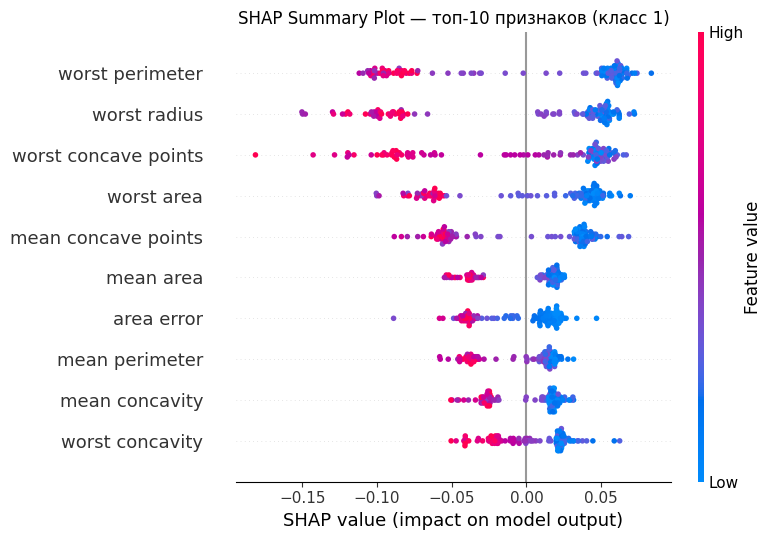

Ранжирование признаков по SHAP (среднее |SHAP|)
                feature  mean_abs_shap
        worst perimeter       0.067861
           worst radius       0.064606
   worst concave points       0.057204
             worst area       0.048771
    mean concave points       0.044888
              mean area       0.024751
             area error       0.023724
         mean perimeter       0.022415
         mean concavity       0.021963
        worst concavity       0.021921
            mean radius       0.018324
          worst texture       0.010934
           mean texture       0.009397
       worst smoothness       0.008549
           radius error       0.008092
      worst compactness       0.007382
        perimeter error       0.005673
       mean compactness       0.004669
         worst symmetry       0.003838
        mean smoothness       0.003456
worst fractal dimension       0.002517
        concavity error       0.001757
       smoothness error       0.001656
      compactnes

In [102]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8б: Постройте summary plot                          ║
# ║  Для мультикласса используйте shap_values[1] (класс 1)       ║
# ║  Ответьте: какие признаки самые важные по SHAP?              ║
# ║  Совпадает ли с PI из шага 6?                                ║
# ╚══════════════════════════════════════════════════════════════╝

# ПРАВКА: Вытаскиваем значения именно для класса 1 (положительного).
# Если массив 3D (shape: объекты, признаки, классы), берем [:, :, 1]
if len(shap_values.shape) == 3:
    shap_matrix = shap_values[:, :, 1]
else:
    shap_matrix = shap_values

# Строим summary plot
plt.figure(figsize=(10, 6))

# Передаем плоскую матрицу shap_matrix
shap.summary_plot(
    shap_matrix, 
    X_test, 
    feature_names=X_test.columns,
    show=False,
    max_display=10
)

plt.title('SHAP Summary Plot — топ-10 признаков (класс 1)')
plt.tight_layout()
plt.show()

# Получаем ранжирование признаков по SHAP
# Теперь shap_matrix строго 2D, и среднее по axis=0 даст строго 1D массив
mean_abs_shap = np.mean(np.abs(shap_matrix), axis=0)

shap_ranking = pd.DataFrame({
    'feature': X_test.columns,
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=False)

print("=" * 60)
print("Ранжирование признаков по SHAP (среднее |SHAP|)")
print("=" * 60)
print(shap_ranking.to_string(index=False))

# Сравнение с Permutation Importance из шага 6
print("\n" + "=" * 60)
print("Сравнение с Permutation Importance")
print("=" * 60)

# Берём топ-5 из SHAP
top5_shap = shap_ranking.head(5)['feature'].tolist()

# Берём топ-5 из PI (из шага 6)
top5_pi = X_test.columns[np.argsort(pi_result['importances_mean'])[::-1][:5]].tolist()

print(f"Топ-5 по SHAP: {top5_shap}")
print(f"Топ-5 по PI:    {top5_pi}")

# Совпадают ли?
overlap = set(top5_shap) & set(top5_pi)
print(f"\nСовпадают: {overlap}")
print(f"Количество совпадений: {len(overlap)} из 5")

if len(overlap) >= 4:
    print("Вывод: Ранжирования в целом совпадают.")
elif len(overlap) >= 2:
    print("Вывод: Есть умеренное совпадение, но различия есть.")
else:
    print("Вывод: Ранжирования сильно различаются — методы измеряют разное.")
    
print("\nПояснение:")
print("- SHAP показывает, как признак влияет на предсказание (на сколько меняет)")
print("- PI показывает, насколько падает качество модели без признака")
print("- Различия могут быть из-за корреляции признаков или нелинейности")

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8в: Найдите объект, на котором модель ошиблась      ║
# ║  (y_pred != y_test). Постройте для него force_plot           ║
# ║  Какие признаки «виноваты» в ошибке?                         ║
# ╚══════════════════════════════════════════════════════════════╝

y_pred_test = best_rf.predict(X_test)
errors = np.where(y_pred_test != y_test)[0]

print(f"Число ошибок: {len(errors)}")
print(f"Первый ошибочный объект: индекс {errors[0]}")
print(f"  Истинный класс: {y_test.iloc[errors[0]]}")
print(f"  Предсказанный класс: {y_pred_test[errors[0]]}")

# YOUR CODE HERE
# shap.force_plot(...)

## Шаг 9. Диагностика подозрительных признаков

Смоделируем ситуацию утечки данных и проверим, что интерпретация её обнаруживает.

In [ ]:
# Добавим два «подозрительных» признака:
# 1. leaky_feature: почти полностью совпадает с таргетом + шум
# 2. random_feature: случайный шум, не связан с таргетом

np.random.seed(42)
X_train_ext = X_train.copy()
X_test_ext = X_test.copy()

X_train_ext['leaky_feature'] = y_train + np.random.normal(0, 0.1, len(y_train))
X_test_ext['leaky_feature'] = y_test + np.random.normal(0, 0.1, len(y_test))

X_train_ext['random_feature'] = np.random.randn(len(y_train))
X_test_ext['random_feature'] = np.random.randn(len(y_test))

print("Добавлены признаки: leaky_feature, random_feature")
print(X_train_ext.tail())

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 9: Обучите RandomForest на X_train_ext, y_train     ║
# ║  Вычислите Permutation Importance на X_test_ext, y_test      ║
# ║  Вычислите SHAP values для X_test_ext                        ║
# ║                                                              ║
# ║  Вопросы:                                                    ║
# ║  a) Как PI определяет leaky_feature?                         ║
# ║     Почему метрика на тесте выросла?                         ║
# ║  б) Как SHAP выделяет leaky_feature в summary plot?          ║
# ║  в) Как обнаружить random_feature как «шумовой»?             ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE

## Шаг 10. Сводная таблица и итоги

Соберём все результаты и сформулируем выводы.

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 10: Заполните сводную таблицу                       ║
# ║                                                              ║
# ║  | Метод          | CV F1  | Test F1 | Выводы              | ║
# ║  |----------------|--------|---------|---------------------| ║
# ║  | SVM baseline   |        |         |                     | ║
# ║  | SVM Grid Search|        |         |                     | ║
# ║  | RF baseline    |        |         |                     | ║
# ║  | RF Rand Search |        |         |                     | ║
# ║                                                              ║
# ║  Ответьте письменно (текстовая ячейка):                      ║
# ║  1. Насколько тюнинг улучшил модели?                         ║
# ║  2. Совпадают ли топ-признаки по PI и SHAP?                  ║
# ║     Если нет — почему?                                       ║
# ║  3. Что было бы, если бы мы не использовали Pipeline?        ║
# ║  4. Как бы вы использовали PI и SHAP в реальном проекте?     ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE

## Шаг 11. (Бонус) Bayesian Optimization с Optuna

Если осталось время — сравните Random Search и Optuna по скорости сходимости.

In [ ]:
# !pip install optuna

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ╔══════════════════════════════════════════════════════════════╗
# ║  БОНУС: Реализуйте objective-функцию для Optuna              ║
# ║  Используйте те же параметры, что в Random Search            ║
# ║  Запустите study.optimize с n_trials=50                      ║
# ║                                                              ║
# ║  Постройте график сходимости:                                ║
# ║  plt.plot(range(n_trials), best_values_over_time)            ║
# ║  Сравните кривые Optuna и Random Search (если логировали)    ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE

def objective(trial):
    # YOUR CODE HERE
    pass

# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=50)
# print(f"Лучший результат Optuna: {study.best_value:.4f}")
# print(f"Лучшие параметры: {study.best_params}")